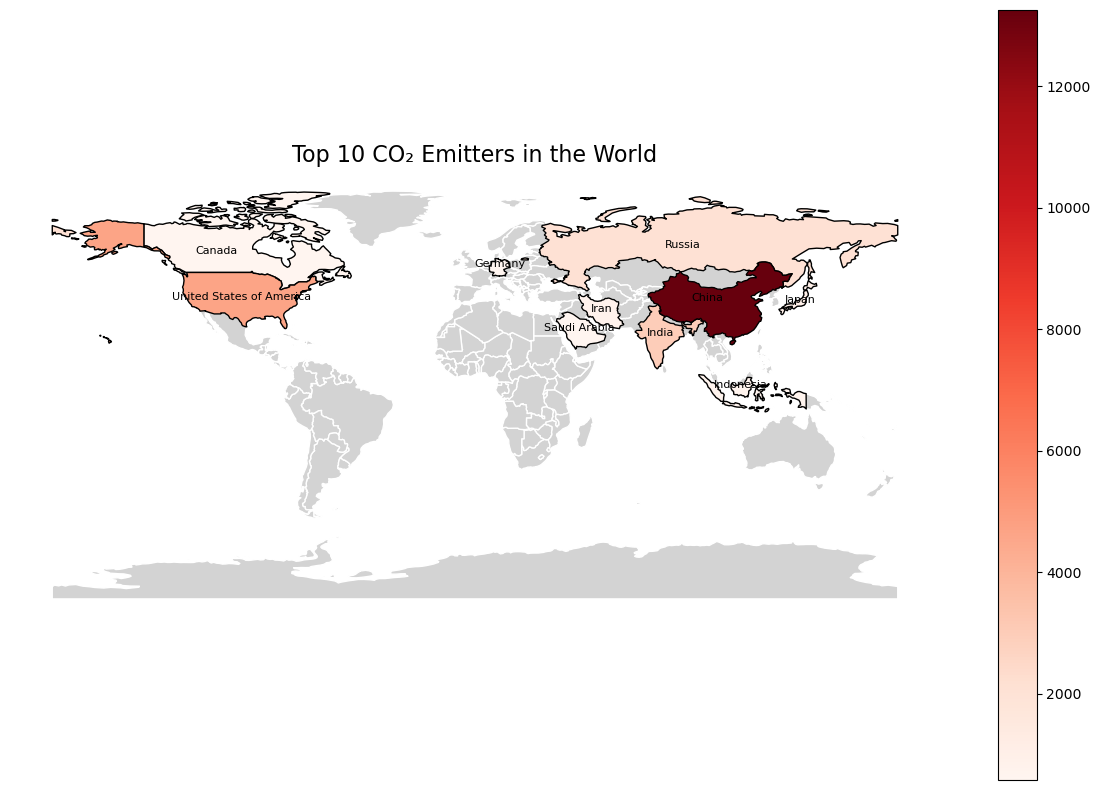

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load map
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Data
data = {
    "country": [
        "China", "United States of America", "India", "Russia",
        "Japan", "Iran", "Indonesia", "Saudi Arabia",
        "Germany", "Canada"
    ],
    "co2": [13260, 4682, 2955, 2070, 945, 779, 675, 623, 583, 575]
}
df = pd.DataFrame(data)

# Merge
merged = world.merge(df, left_on="ADMIN", right_on="country", how="left")

# FIX: only filter on CO2
emitters = merged[merged["co2"].notna()]

# Plot
fig, ax = plt.subplots(figsize=(15, 10))

# Base map
world.plot(ax=ax, color="lightgray", edgecolor="white")

# Highlight emitters
emitters.plot(
    ax=ax,
    column="co2",
    cmap="Reds",
    legend=True,
    edgecolor="black"
)

# Labels
for _, row in emitters.iterrows():
    point = row["geometry"].representative_point()
    ax.text(point.x, point.y, row["country"], fontsize=8, ha="center")

# EXTRA SAFETY (prevents ellipse / aspect bugs)
ax.set_aspect('equal')

ax.set_title("Top 10 CO₂ Emitters in the World", fontsize=16)
ax.axis("off")

plt.show()

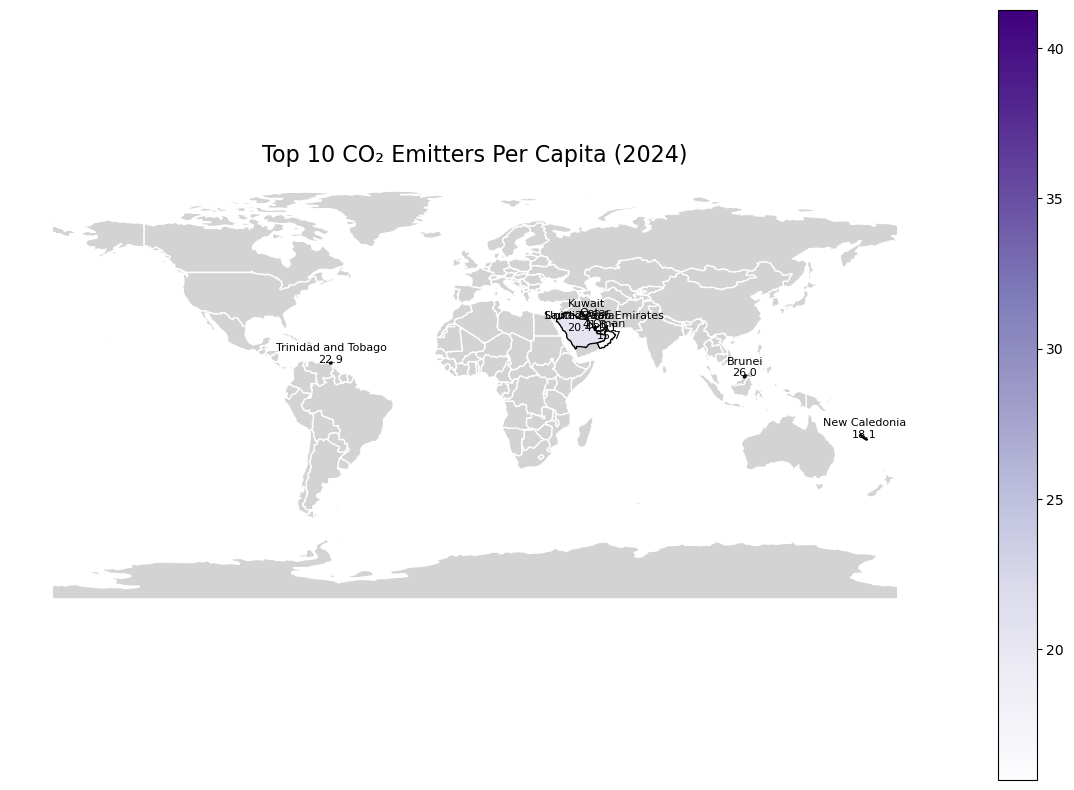

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load world map
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Load OWID CO2 dataset
owid_url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(owid_url)

# Keep only countries (filter out aggregates like "World", "Asia", etc.)
df = df[df["iso_code"].str.len() == 3]

# Use most recent year
latest_year = df["year"].max()
df_latest = df[df["year"] == latest_year]

# Select relevant columns
df_latest = df_latest[["country", "co2_per_capita"]].dropna()

# Get top 10 per capita emitters
top10 = df_latest.sort_values("co2_per_capita", ascending=False).head(10)

# Fix country names to match Natural Earth
name_fix = {
    "United States": "United States of America",
    "Democratic Republic of Congo": "Dem. Rep. Congo",
    "Czechia": "Czech Republic"
}
top10["country"] = top10["country"].replace(name_fix)

# Merge with map
merged = world.merge(top10, left_on="ADMIN", right_on="country", how="left")

# Filter emitters
emitters = merged[merged["co2_per_capita"].notna()]

# Plot
fig, ax = plt.subplots(figsize=(15, 10))

# Base map
world.plot(ax=ax, color="lightgray", edgecolor="white")

# Highlight top 10 per capita
emitters.plot(
    ax=ax,
    column="co2_per_capita",
    cmap="Purples",
    legend=True,
    edgecolor="black"
)

# Labels
for _, row in emitters.iterrows():
    point = row["geometry"].representative_point()
    ax.text(
        point.x, point.y,
        f"{row['country']}\n{row['co2_per_capita']:.1f}",
        fontsize=8, ha="center"
    )

ax.set_title(f"Top 10 CO₂ Emitters Per Capita ({latest_year})", fontsize=16)
ax.set_aspect('equal')
ax.axis("off")

plt.show()